# Librerie

In [1]:
!pip install obspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 41.9 MB/s eta 0:00:00


In [1]:
from obspy import read, Stream
from obspy.clients.fdsn import Client
from obspy.clients.fdsn.header import FDSNNoDataException
from obspy import UTCDateTime
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
import plotly.graph_objects as go

import numpy as np
import pandas as pd

Mounted at /content/drive


# KVG Catalog

## Coordinates fot Every Station

In [4]:
client = Client("https://geofon.gfz-potsdam.de")
tstart = UTCDateTime("2015-07-01 00:00:00")
tend   = UTCDateTime("2016-07-31 00:00:00")

inv = client.get_stations(network="X9",  starttime=tstart, endtime=tend, channel="*HN")
# print(inv)
nsta = np.shape(inv)[1]

# stla = np.zeros(nsta)
# stlo = np.zeros(nsta)
coordinates_for_station = {}
stname = []

for i in range(0,nsta):
    coordinates_for_station[inv[0][i].code] = [inv[0][i].latitude,inv[0][i].longitude]

## Catalog

In [5]:
catalog = pd.read_csv(
    '/content/drive/MyDrive/KVG_catalog.txt',
    sep=',',
    header=None,
    names=['time', 'lat', 'lon', 'depth_km', 'mag'],
)
catalog['time'] = pd.to_datetime(catalog['time'])
catalog['index'] = [f"Event {i}" for i in range(1,len(catalog)+1)]
catalog = catalog.set_index("index")


print(f"Loaded {len(catalog)} events")
print(f"Time range: {catalog['time'].min()} to {catalog['time'].max()}")
print(f"Magnitude range: {catalog['mag'].min():.1f} – {catalog['mag'].max():.1f}")
catalog.head()

Loaded 11209 events
Time range: 2015-08-03 14:56:47.810000+00:00 to 2016-07-04 21:46:56.760000+00:00
Magnitude range: 0.0 – 3.1


,time,lat,lon,depth_km,mag
index,,,,,
Event 1,2015-08-03 14:56:47.810000+00:00,56.051729,160.607292,30.49,1.42
Event 2,2015-08-05 02:33:26.280000+00:00,56.027136,160.655599,31.35,2.01
Event 3,2015-08-06 02:11:34.860000+00:00,56.038220,160.563005,29.36,1.97
Event 4,2015-08-06 08:01:51.920000+00:00,56.051261,160.605957,29.73,1.96
Event 5,2015-08-06 10:07:05.340000+00:00,56.067623,160.550732,43.55,1.86


## Phase Data

In [6]:
stations_for_event = {}
SV13_Events = []
i=0
with open("/content/drive/MyDrive/KVG_phase_data.txt", "r", encoding="UTF-8") as f:
    date = -1
    line = f.readline()

    while line != "":
        check = line[:2]
        match check:
            case "X9":
                datas = line.split(",")
                #                                              NOME STAZIONE     P TIME   S TIME
                stations_for_event.setdefault(f"Event {i}", {})[datas[0][3:]] = (datas[1],datas[2])
                if datas[0][3:] == "SV13": SV13_Events.append(f"Event {i}")

            case "D0":
                pass

            case _:
                date = line.split(",")[0]
                i+=1
        line = f.readline()

# Registrations for a single event

In [ ]:
EVENT = "Event 69" # Eventi da 1 a 11209
STATIONS = list(stations_for_event[f"Event {i}"].keys())[::-1][:5]

PRE_S       = 10   # seconds before origin time
POST_S      = 60   # seconds after origin time


T = UTCDateTime(catalog.loc[EVENT, 'time'].timestamp())
Events = []
for index, Station in enumerate(STATIONS):
  try:
      st = client.get_waveforms(
          network="X9",
          station=Station,
          location="*",
          channel="*",
          starttime=T - PRE_S,
          endtime=T + POST_S)
      print(f"{len(st)} Tracce Trovate per {Station}\n")
      Events.append((Station, st))

  except FDSNNoDataException:
      print(f"Errore per la stazione {Station}\n")
      pass

# Smoothing
for row, st in Events:
  for tr in st:

    tr.detrend("demean")
    tr.detrend("linear")

    tr.filter(
        "bandpass",
        freqmin=1,
        freqmax=20,
        corners=4,
        zerophase=True)

## Plots of the area

In [ ]:
for St, _ in Events:

  lat, lon = coordinates_for_station[St][0], coordinates_for_station[St][1]
  plt.scatter(lon, lat, marker="o", color="blue")
  plt.annotate(St, (lon, lat), textcoords="offset points", xytext=(0, -10), ha="center", fontsize=7, color="blue")

plt.scatter(catalog.loc[EVENT, "lon"], catalog.loc[EVENT, "lat"], marker="x", color="red")

plt.scatter([], [], marker="x", color="red", label="Event")
plt.scatter([], [], marker="o", color="blue", label="Stations")

plt.legend()
plt.grid("on",alpha=0.3)
plt.show()

## Plot Waveforms

Stazione SV13



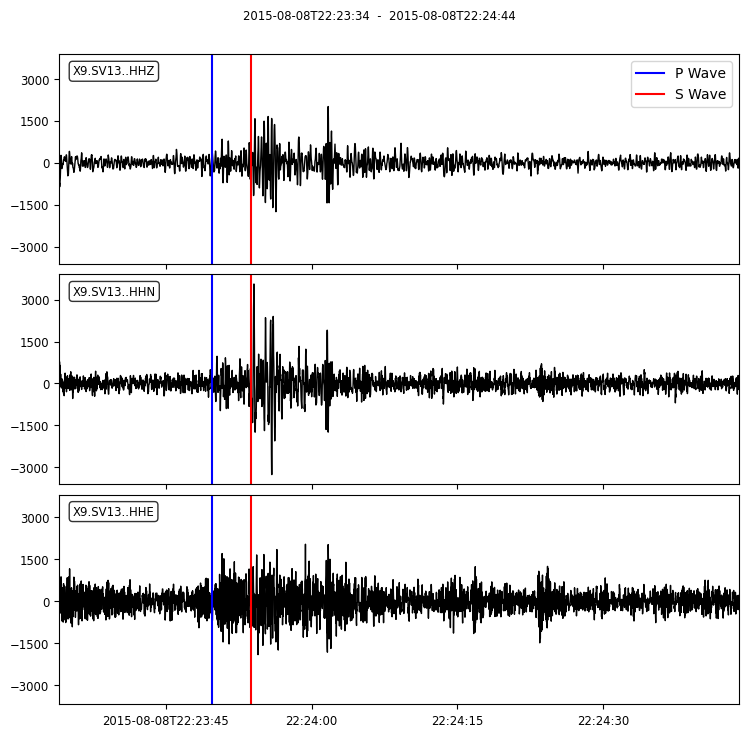

In [ ]:
Plotting = Events[np.random.randint(0, len(Events))-1]

P_Wave = UTCDateTime(stations_for_event[EVENT][Plotting[0]][0]).datetime
S_Wave = UTCDateTime(stations_for_event[EVENT][Plotting[0]][1]).datetime

print(f"Stazione {Plotting[0]}\n")
fig = Plotting[1].plot(show=False)
fig.subplots_adjust(hspace=0.05)
for i in range(len(fig.axes)):
  ax = fig.axes[i]
  ax.axvline(P_Wave, color='blue', label = "P Wave")
  ax.axvline(S_Wave, color='red', label = "S Wave")
fig.axes[0].legend(loc = "upper right")
display(fig)

# Multiple Events for SV13 Station

In [ ]:
EVENTS = SV13_Events[:5]
STATION = "SV13"

PRE_S       = 10   # seconds before origin time
POST_S      = 50   # seconds after origin time

Events = []
for E in EVENTS:
  T = UTCDateTime(catalog.loc[E, 'time'].timestamp())
  try:
      st = client.get_waveforms(
          network="X9",
          station="SV13",
          location="*",
          channel="*",
          starttime=T - PRE_S,
          endtime=T + POST_S)
      print(f"{len(st)} Tracce Trovate per {E}\n")
      Events.append((E, st))

  except FDSNNoDataException:
      print(f"SV13 Non ha registrazione per {E}\n")
      pass

# Smoothing
for E, st in Events:
  for tr in st:

    tr.detrend("demean")
    tr.detrend("linear")

    tr.filter(
        "bandpass",
        freqmin=1,
        freqmax=20,
        corners=4,
        zerophase=True)

## Plots of the area

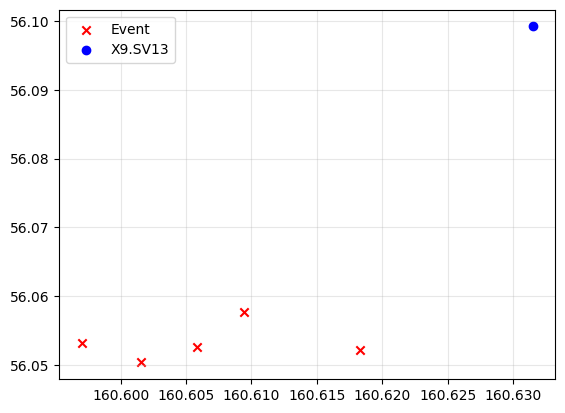

In [18]:
for E, _ in Events:
  plt.scatter(catalog.loc[E, "lon"], catalog.loc[E, "lat"], marker="x", color="red")

plt.scatter(coordinates_for_station["SV13"][1], coordinates_for_station["SV13"][0], marker="o", color="blue")

plt.scatter([], [], marker="x", color="red", label="Event")
plt.scatter([], [], marker="o", color="blue", label="X9.SV13")

plt.legend()
plt.grid("on",alpha=0.3)
plt.show()

## Plot Waveforms

Event 69


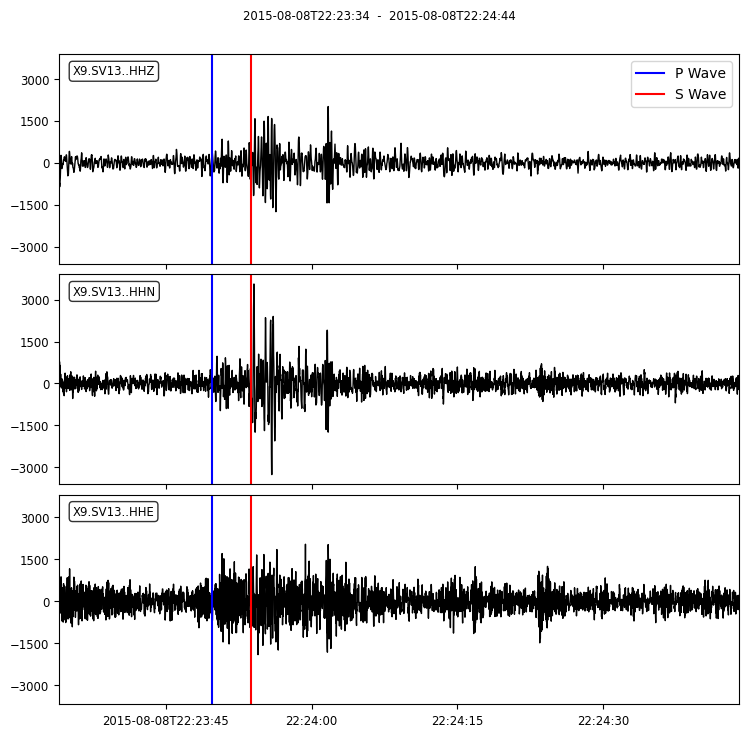

In [21]:
Plotting = Events[np.random.randint(0, len(Events))-1]

P_Wave = UTCDateTime(stations_for_event[Plotting[0]]["SV13"][0]).datetime
S_Wave = UTCDateTime(stations_for_event[Plotting[0]]["SV13"][1]).datetime

print(Plotting[0])

fig = Plotting[1].plot(show=False)
fig.subplots_adjust(hspace=0.05)
for i in range(len(fig.axes)):
  ax = fig.axes[i]
  ax.axvline(P_Wave, color='blue', label = "P Wave")
  ax.axvline(S_Wave, color='red', label = "S Wave")
fig.axes[0].legend(loc = "upper right")
display(fig)

# Plot del Catalog

## 3D

In [ ]:
Latitudini = catalog["lat"].values
Longitudini = catalog["lon"].values
Profondità = catalog["depth_km"].values

fig = go.Figure(data=[go.Scatter3d(
    x = Latitudini,
    y = Longitudini,
    z = Profondità,
    mode='markers',
    marker=dict(
        size=2,
        color='black')
    )])

fig.update_layout(
    scene=dict(
        zaxis=dict(autorange="reversed")))

fig.show()

## Number Of ebents Over Time

/tmp/ipykernel_1576/2165308494.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  counts = catalog["time"].dt.to_period("W").value_counts()


Text(0, 0.5, 'N. eventi per settimana')

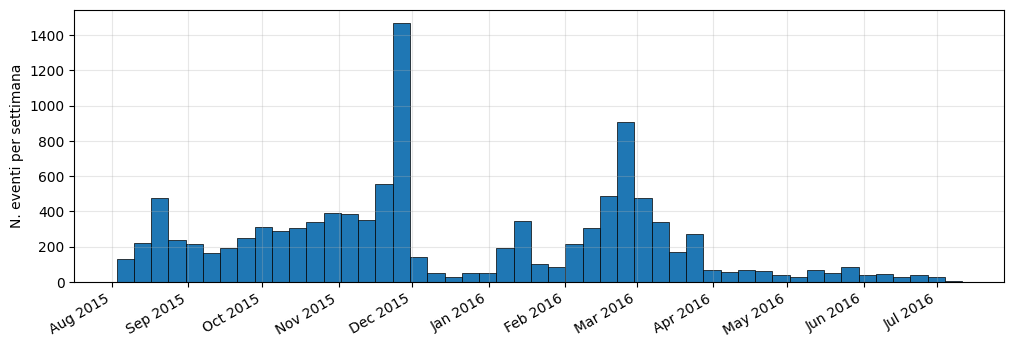

In [37]:
counts = catalog["time"].dt.to_period("W").value_counts()
counts.index = counts.index.to_timestamp()


fig, ax = plt.subplots(figsize=(12, 4))

ax.xaxis.set_major_locator(mdates.MonthLocator())          # un tick al mese
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()

ax.bar(counts.index, counts.values, width=7, align="edge", edgecolor="black", linewidth=0.5)
ax.grid("on", alpha = 0.3)
ax.set_ylabel("N. eventi per settimana")

# Magnitude of events over time

Text(0, 0.5, 'Magnitude')

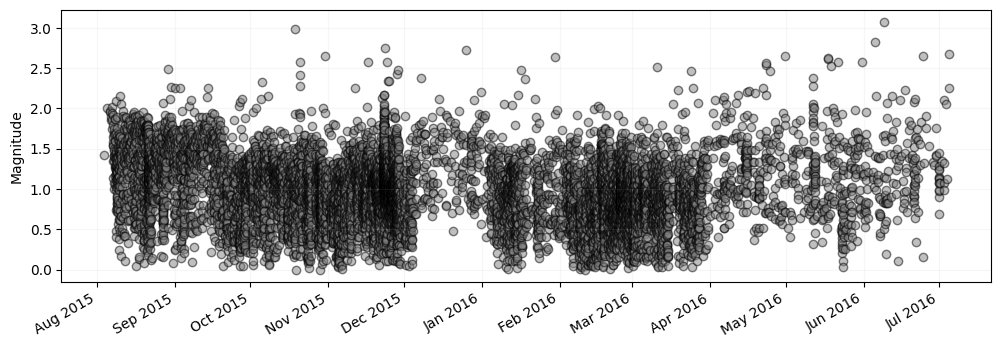

In [46]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.xaxis.set_major_locator(mdates.MonthLocator())          # un tick al mese
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()

ax.scatter(catalog["time"], catalog["mag"], marker="o", color="grey", alpha = 0.5, edgecolor = "black")
ax.grid("on", alpha = 0.1)
ax.set_ylabel("Magnitude")